<a href="https://colab.research.google.com/github/canunz/EV3_outfits/blob/main/CNN_Simpsons_Evaluacion2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°2 – Implementación y Optimización de Redes Convolucionales
**Asignatura:** Deep Learning (DLY0100)  
**Caso de estudio:** Clasificación de personajes de Los Simpsons

**Integrantes:**
- Carolina Cheuquepil
- Angelina Mendoza
- Catalina Nuñez
- Paloma Tamayo

---

## 1. Introducción

El objetivo de este trabajo es construir una Red Neuronal Convolucional (CNN) capaz de clasificar imágenes de 25 personajes distintos de Los Simpsons.

Una CNN es un tipo de red neuronal diseñada para trabajar con imágenes. A diferencia de una red MLP que conecta todos los píxeles con todas las neuronas (lo que genera millones de parámetros), la CNN usa **filtros/kernels** que recorren la imagen y extraen características como bordes, texturas y formas. Esto reduce drásticamente la cantidad de parámetros y mejora el rendimiento.

**Arquitectura general que usaremos:**
```
Imagen → [Conv → ReLU → Pooling] x N → Flatten → Dense → Softmax → Clase predicha
```

**Estrategia del trabajo:**
1. Primero entrenamos una CNN simple (Modelo Base)
2. Luego la mejoramos con más capas + Dropout (Modelo Mejorado)
3. Finalmente comparamos ambas arquitecturas y elegimos la mejor

## 2. Carga y Preprocesamiento de Datos

Primero subimos el dataset a Colab. El archivo `archive.zip` contiene dos carpetas: `train/` y `test/`, cada una con subcarpetas por personaje.

**Preprocesamiento que aplicamos:**
- Redimensionar todas las imágenes a 64×64 píxeles (tamaño fijo)
- Normalizar los valores de píxeles al rango [0, 1] dividiendo por 255
- Data Augmentation en entrenamiento: rotaciones, flips horizontales y zoom para que el modelo generalice mejor

In [ ]:
# Subimos el archivo ZIP
from google.colab import files
import zipfile, os

print("Selecciona el archivo archive.zip desde tu computador...")
archivo = files.upload()  # Se abre el explorador de archivos

# Tomamos el nombre del archivo subido
nombre_zip = list(archivo.keys())[0]
print(f"Archivo recibido: {nombre_zip}")

# Descomprimimos el dataset
with zipfile.ZipFile(nombre_zip, "r") as zip_ref:
    zip_ref.extractall("simpsons_dataset")

print("Dataset descomprimido correctamente")
print("Contenido:", os.listdir("simpsons_dataset"))

Selecciona el archivo archive.zip desde tu computador...


Saving archive (2).zip to archive (2).zip
Archivo recibido: archive (2).zip
Dataset descomprimido correctamente
Contenido: ['test', 'train']


In [ ]:
# Importamos todas las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Fijamos semillas para reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow versión:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

TensorFlow versión: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Definimos los parámetros base del dataset
IMG_SIZE = 64        # Redimensionamos a 64x64 px
BATCH_SIZE = 32      # Cuántas imágenes procesamos a la vez
NUM_CLASES = 25      # Tenemos 25 personajes distintos

TRAIN_DIR = 'simpsons_dataset/train'
TEST_DIR  = 'simpsons_dataset/test'

# Verificamos cuántas clases hay
clases = sorted(os.listdir(TRAIN_DIR))
print(f'Número de clases: {len(clases)}')
print('Personajes:', clases)

Número de clases: 25
Personajes: ['abraham_grampa_simpson', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson', 'charles_montgomery_burns', 'chief_wiggum', 'comic_book_guy', 'edna_krabappel', 'groundskeeper_willie', 'homer_simpson', 'kent_brockman', 'krusty_the_clown', 'lenny_leonard', 'lisa_simpson', 'maggie_simpson', 'marge_simpson', 'mayor_quimby', 'milhouse_van_houten', 'moe_szyslak', 'ned_flanders', 'nelson_muntz', 'principal_skinner', 'selma_bouvier', 'sideshow_bob', 'waylon_smithers']


In [ ]:
# --- DATA AUGMENTATION ---
# Al entrenamiento le aplicamos transformaciones aleatorias para que
# el modelo no 'memorice' las imágenes y generalice mejor.
# Al test solo normalizamos (no queremos modificar las imágenes de prueba)

train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normaliza píxeles a [0,1]
    rotation_range=20,        # Rotación aleatoria hasta 20 grados
    width_shift_range=0.1,    # Desplazamiento horizontal
    height_shift_range=0.1,   # Desplazamiento vertical
    horizontal_flip=True,     # Voltear imagen horizontalmente
    zoom_range=0.1,           # Zoom aleatorio
    validation_split=0.2      # 20% de train lo usamos como validación
)

test_datagen = ImageDataGenerator(rescale=1./255)  # Solo normalización

# Generadores de datos
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # Importante: no mezclar para evaluar bien
)

Found 12920 images belonging to 25 classes.
Found 3217 images belonging to 25 classes.
Found 3937 images belonging to 25 classes.


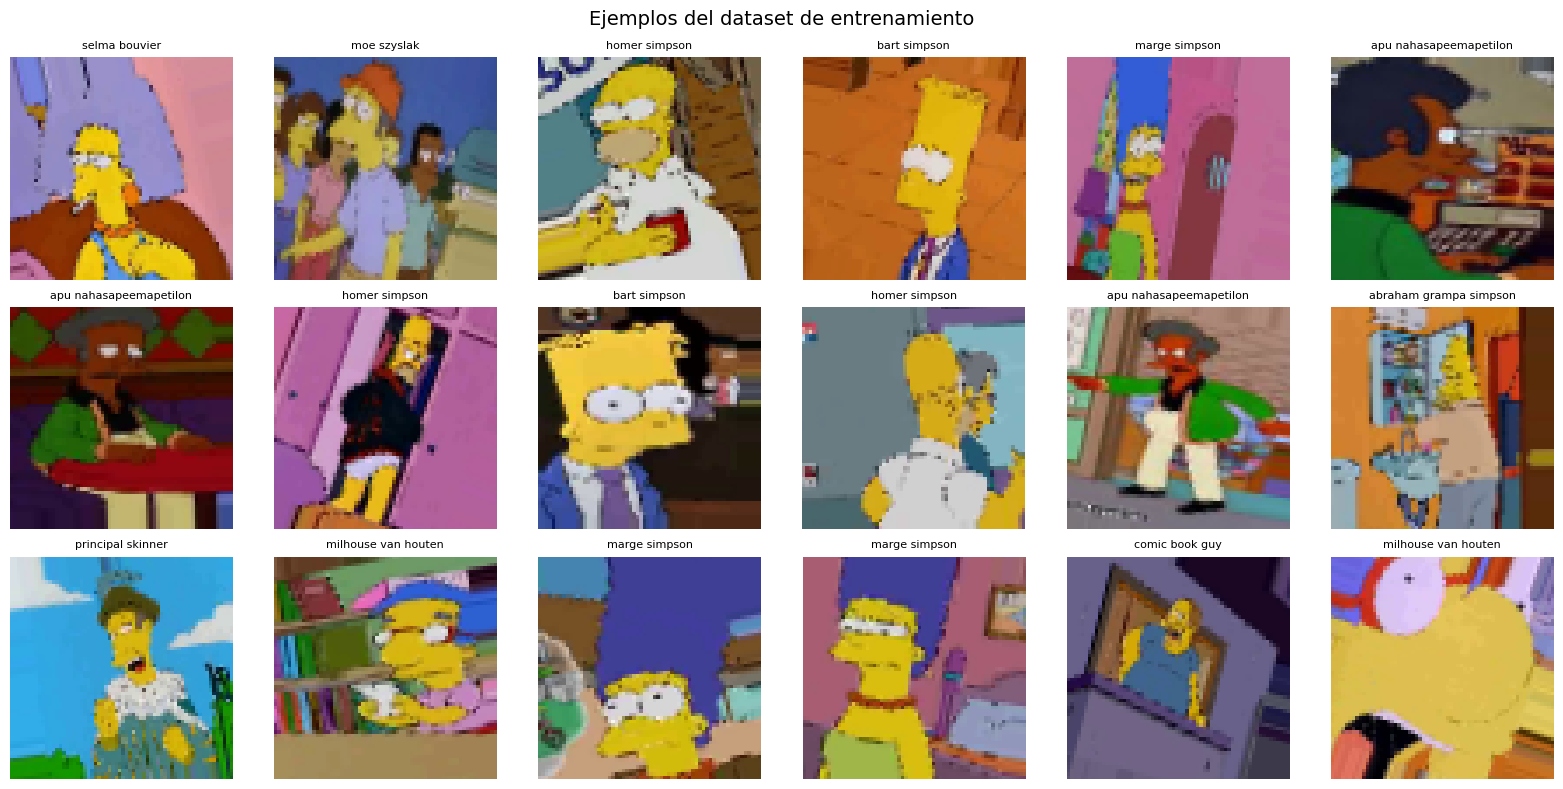

In [ ]:
# Visualizamos algunas imágenes del dataset para entender los datos
imagenes, etiquetas = next(train_gen)
nombres_clases = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(imagenes[i])
    clase_idx = np.argmax(etiquetas[i])
    ax.set_title(nombres_clases[clase_idx].replace('_', ' '), fontsize=8)
    ax.axis('off')
plt.suptitle('Ejemplos del dataset de entrenamiento', fontsize=14)
plt.tight_layout()
plt.show()


Se redimensionaron todas las imágenes a 64x64 píxeles para estandarizar la entrada del modelo y reducir el costo computacional durante el entrenamiento. Posteriormente, se normalizaron los valores de los píxeles al rango [0,1], favoreciendo una convergencia más estable de la red neuronal.

Además, se aplicaron técnicas de Data Augmentation en el conjunto de entrenamiento, incluyendo rotaciones, desplazamientos, zoom y volteo horizontal. Estas transformaciones permiten aumentar artificialmente la variedad de ejemplos disponibles, reduciendo el riesgo de sobreajuste y mejorando la capacidad de generalización del modelo.

## 3. Modelo Base – CNN Simple

Comenzamos con una arquitectura básica que vimos en clases:

**Arquitectura:**
```
Conv2D(32, 3x3) → ReLU → MaxPooling(2x2)
Conv2D(64, 3x3) → ReLU → MaxPooling(2x2)
Flatten
Dense(128) → ReLU
Dense(25)  → Softmax
```

**Hiperparámetros clave:**
- **Filtros:** 32 y 64 (aumentan progresivamente para capturar más características)
- **Kernel:** 3×3 (tamaño estándar, captura patrones locales)
- **Pooling:** 2×2 reduce la dimensión a la mitad en cada capa
- **ReLU:** función de activación no lineal, elimina valores negativos
- **Softmax:** convierte la salida en probabilidades para cada clase
- **Optimizador:** Adam con lr=0.001
- **Loss:** categorical_crossentropy (para clasificación multiclase)

In [ ]:
# Construimos el modelo base
def crear_modelo_base():
    modelo = keras.Sequential([
        # Bloque 1: primera capa convolucional
        # 32 filtros de 3x3, la red aprende 32 tipos de características
        layers.Conv2D(32, (3, 3), activation='relu',
                      input_shape=(IMG_SIZE, IMG_SIZE, 3), padding='same'),
        layers.MaxPooling2D((2, 2)),  # Reduce de 64x64 a 32x32

        # Bloque 2: segunda capa convolucional con más filtros
        # Aumentamos a 64 filtros para capturar características más complejas
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),  # Reduce de 32x32 a 16x16

        # Aplanamos el mapa de características a un vector 1D
        layers.Flatten(),

        # Capas densas (fully connected) para clasificación final
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASES, activation='softmax')  # 25 clases
    ])
    return modelo

modelo_base = crear_modelo_base()

# Compilamos el modelo
modelo_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostramos la arquitectura
modelo_base.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,119,897 (8.09 MB)

 Trainable params: 2,119,897 (8.09 MB)

 Non-trainable params: 0 (0.00 B)

El modelo base se construyó con dos bloques convolucionales para establecer una arquitectura inicial simple. Se utilizaron filtros 32 y 64 para capturar características visuales progresivamente más complejas. Esta arquitectura sirve como punto de comparación para evaluar si una red más profunda mejora el rendimiento.

In [ ]:
# Entrenamos el modelo base (20 épocas para tener un resultado rápido)
print('Entrenando modelo base...')

historial_base = modelo_base.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    verbose=1
)

print('Entrenamiento completado!')

Entrenando modelo base...
Epoch 1/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 51s 116ms/step - accuracy: 0.3269 - loss: 2.3337 - val_accuracy: 0.4632 - val_loss: 1.9410
Epoch 2/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 40s 100ms/step - accuracy: 0.5042 - loss: 1.7309 - val_accuracy: 0.5185 - val_loss: 1.7169
Epoch 3/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - accuracy: 0.5800 - loss: 1.4644 - val_accuracy: 0.5825 - val_loss: 1.4794
Epoch 4/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.6259 - loss: 1.2964 - val_accuracy: 0.6298 - val_loss: 1.3217
Epoch 5/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.6648 - loss: 1.1543 - val_accuracy: 0.6400 - val_loss: 1.2587
Epoch 6/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.6899 - loss: 1.0479 - val_accuracy: 0.6491 - val_loss: 1.2348
Epoch 7/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.7171 - loss: 0.9698 - val_accuracy: 0.6749 - val_loss: 1.1447
Epoch 8/20
404/404 ━━━━━━━━━━━━━━━━━━━━ 42s 104ms/step - 

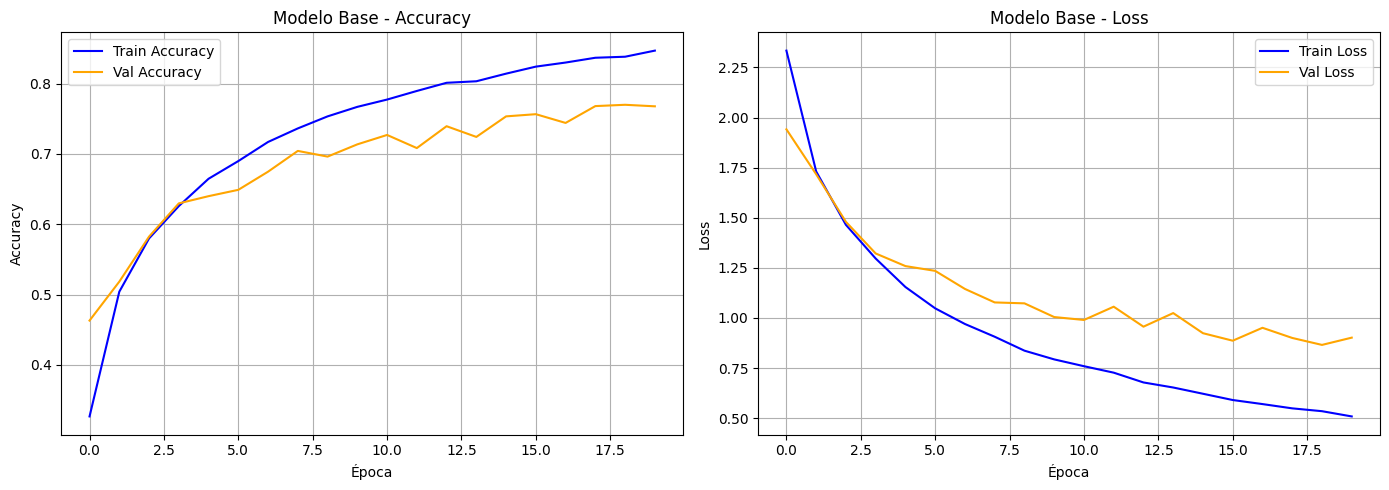

In [ ]:
# Función reutilizable para graficar curvas de aprendizaje
def graficar_historial(historial, titulo='Curvas de Aprendizaje'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico de Accuracy
    ax1.plot(historial.history['accuracy'],     label='Train Accuracy', color='blue')
    ax1.plot(historial.history['val_accuracy'], label='Val Accuracy',   color='orange')
    ax1.set_title(f'{titulo} - Accuracy')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Gráfico de Loss
    ax2.plot(historial.history['loss'],     label='Train Loss', color='blue')
    ax2.plot(historial.history['val_loss'], label='Val Loss',   color='orange')
    ax2.set_title(f'{titulo} - Loss')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

graficar_historial(historial_base, 'Modelo Base')

### Análisis del Modelo Base

Al observar las curvas de aprendizaje podemos identificar si hay **overfitting** (sobreajuste): cuando la accuracy de entrenamiento sube pero la de validación se estanca o baja, significa que el modelo está memorizando los datos en lugar de aprender patrones generales.

Con una CNN simple de solo 2 capas convolucionales esperamos ver overfitting considerable, ya que la red tiene capacidad limitada para generalizar en un dataset de 25 clases.

Observando las curvas de entrenamiento y validación, se aprecia una diferencia creciente entre ambas métricas a medida que avanzan las épocas. Esto sugiere la presencia de sobreajuste, ya que el modelo continúa mejorando sobre los datos de entrenamiento mientras la mejora en validación es más limitada.

Además, la arquitectura base posee únicamente dos bloques convolucionales, lo que restringe su capacidad para capturar patrones visuales complejos en un problema de clasificación con 25 clases distintas.

## 4. Modelo Mejorado – CNN con Más Capas y Dropout

Para mejorar el rendimiento y reducir el overfitting aplicamos:

1. **Más capas convolucionales** (3 bloques en vez de 2) → captura características más complejas
2. **BatchNormalization** → estabiliza el entrenamiento, acelera la convergencia
3. **Dropout** → desactiva neuronas aleatoriamente durante el entrenamiento para evitar overfitting
4. **Más filtros** (hasta 128) → mayor capacidad de aprendizaje

**Nueva arquitectura:**
```
Conv(32) → BN → ReLU → Conv(32) → BN → ReLU → MaxPool → Dropout(0.25)
Conv(64) → BN → ReLU → Conv(64) → BN → ReLU → MaxPool → Dropout(0.25)
Conv(128)→ BN → ReLU → MaxPool → Dropout(0.25)
Flatten → Dense(256) → BN → ReLU → Dropout(0.5)
Dense(25) → Softmax
```

In [ ]:
# Modelo mejorado con más capas, BatchNorm y Dropout
def crear_modelo_mejorado():
    modelo = keras.Sequential([
        # --- Bloque 1: dos conv de 32 filtros ---
        layers.Conv2D(32, (3,3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),  # Desactiva 25% de neuronas en cada paso

        # --- Bloque 2: dos conv de 64 filtros ---
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # --- Bloque 3: una conv de 128 filtros ---
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # --- Clasificador fully connected ---
        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),  # 50% dropout en la capa densa es común
        layers.Dense(NUM_CLASES, activation='softmax')
    ])
    return modelo

modelo_mejorado = crear_modelo_mejorado()

# Usamos learning rate scheduler: empieza con lr=0.001 y baja si la validación no mejora
modelo_mejorado.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_mejorado.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,245,561 (8.57 MB)

 Trainable params: 2,244,409 (8.56 MB)

 Non-trainable params: 1,152 (4.50 KB)

### Análisis del Modelo Mejorado

Las curvas de entrenamiento muestran una convergencia más estable que en el modelo base. La incorporación de BatchNormalization permitió reducir las fluctuaciones durante el aprendizaje, mientras que Dropout contribuyó a disminuir el sobreajuste.

Asimismo, la utilización de EarlyStopping evitó continuar entrenando una vez alcanzado el mejor desempeño de validación, permitiendo conservar los pesos óptimos del modelo.

### Ajustes de hiperparámetros

Durante el desarrollo se realizaron modificaciones sobre la arquitectura base para mejorar el rendimiento del modelo.

Se aumentó la profundidad de la red, pasando de dos bloques convolucionales en el modelo base a tres bloques en el modelo mejorado. También se incrementó la cantidad máxima de filtros desde 64 hasta 128, permitiendo capturar patrones visuales más complejos.

Además, se incorporó BatchNormalization para estabilizar el entrenamiento y Dropout con tasas de 0.25 y 0.50 para reducir el sobreajuste. También se utilizaron callbacks como EarlyStopping, ReduceLROnPlateau y ModelCheckpoint para optimizar el entrenamiento, evitar entrenar de más y conservar el mejor modelo obtenido.

### Resumen de hiperparámetros utilizados

| Parámetro | Modelo Base | Modelo Mejorado |
|------------|------------|------------|
| Tamaño imagen | 64x64 | 64x64 |
| Batch Size | 32 | 32 |
| Learning Rate | 0.001 | 0.001 |
| Épocas máximas | 20 | 40 |
| Bloques convolucionales | 2 | 3 |
| Filtros máximos | 64 | 128 |
| BatchNormalization | No | Sí |
| Dropout | No | 0.25 y 0.50 |
| EarlyStopping | No | Sí |
| ReduceLROnPlateau | No | Sí |

In [ ]:
# Callbacks: herramientas que ayudan durante el entrenamiento
callbacks = [
    # Reduce el learning rate cuando val_loss no mejora en 3 épocas
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, verbose=1
    ),
    # Para el entrenamiento si val_loss no mejora en 8 épocas (evita entrenar de más)
    keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True, verbose=1
    ),
    # Guarda el mejor modelo
    keras.callbacks.ModelCheckpoint(
        'mejor_modelo.h5', monitor='val_accuracy', save_best_only=True, verbose=1
    )
]

print('Entrenando modelo mejorado...')

historial_mejorado = modelo_mejorado.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

print('Entrenamiento completado!')

Entrenando modelo mejorado...
Epoch 1/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2656 - loss: 2.7315
Epoch 1: val_accuracy improved from None to 0.28007, saving model to mejor_modelo.h5



Epoch 1: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 66s 133ms/step - accuracy: 0.3493 - loss: 2.3407 - val_accuracy: 0.2801 - val_loss: 2.7855 - learning_rate: 0.0010
Epoch 2/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.5087 - loss: 1.7336
Epoch 2: val_accuracy improved from 0.28007 to 0.54989, saving model to mejor_modelo.h5



Epoch 2: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 44s 108ms/step - accuracy: 0.5275 - loss: 1.6494 - val_accuracy: 0.5499 - val_loss: 1.5970 - learning_rate: 0.0010
Epoch 3/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6073 - loss: 1.3767
Epoch 3: val_accuracy improved from 0.54989 to 0.59248, saving model to mejor_modelo.h5



Epoch 3: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 106ms/step - accuracy: 0.6167 - loss: 1.3433 - val_accuracy: 0.5925 - val_loss: 1.3541 - learning_rate: 0.0010
Epoch 4/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6599 - loss: 1.1798
Epoch 4: val_accuracy improved from 0.59248 to 0.65185, saving model to mejor_modelo.h5



Epoch 4: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - accuracy: 0.6657 - loss: 1.1678 - val_accuracy: 0.6518 - val_loss: 1.2254 - learning_rate: 0.0010
Epoch 5/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.6903 - loss: 1.0621
Epoch 5: val_accuracy did not improve from 0.65185
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.6997 - loss: 1.0302 - val_accuracy: 0.5176 - val_loss: 1.7776 - learning_rate: 0.0010
Epoch 6/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.7228 - loss: 0.9261
Epoch 6: val_accuracy improved from 0.65185 to 0.70687, saving model to mejor_modelo.h5


...


Epoch 29: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 100ms/step - accuracy: 0.9199 - loss: 0.2688 - val_accuracy: 0.9120 - val_loss: 0.3520 - learning_rate: 2.5000e-04
Epoch 30/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9212 - loss: 0.2544
Epoch 30: val_accuracy did not improve from 0.91203
404/404 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - accuracy: 0.9191 - loss: 0.2658 - val_accuracy: 0.9027 - val_loss: 0.3741 - learning_rate: 2.5000e-04
Epoch 31/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9272 - loss: 0.2463
Epoch 31: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 31: val_accuracy did not improve from 0.91203
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 102ms/step - accuracy: 0.9242 - loss: 0.2563 - val_accuracy: 0.9055 - val_loss: 0.3676 - learning_rate: 2.5000e-04
Epoch 32/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9278 - loss: 0.2391
Epoch 32: val_accuracy improved from 0.91203 to 0.91265, s


Epoch 32: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - accuracy: 0.9263 - loss: 0.2441 - val_accuracy: 0.9127 - val_loss: 0.3432 - learning_rate: 1.2500e-04
Epoch 33/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9234 - loss: 0.2423
Epoch 33: val_accuracy improved from 0.91265 to 0.91638, saving model to mejor_modelo.h5



Epoch 33: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 44s 108ms/step - accuracy: 0.9292 - loss: 0.2340 - val_accuracy: 0.9164 - val_loss: 0.3419 - learning_rate: 1.2500e-04
Epoch 34/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9274 - loss: 0.2423
Epoch 34: val_accuracy did not improve from 0.91638
404/404 ━━━━━━━━━━━━━━━━━━━━ 41s 101ms/step - accuracy: 0.9249 - loss: 0.2454 - val_accuracy: 0.9154 - val_loss: 0.3239 - learning_rate: 1.2500e-04
Epoch 35/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9235 - loss: 0.2453
Epoch 35: val_accuracy did not improve from 0.91638
404/404 ━━━━━━━━━━━━━━━━━━━━ 42s 103ms/step - accuracy: 0.9255 - loss: 0.2420 - val_accuracy: 0.9164 - val_loss: 0.3358 - learning_rate: 1.2500e-04
Epoch 36/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9315 - loss: 0.2299
Epoch 36: val_accuracy improved from 0.91638 to 0.92073, saving model to mejor_modelo.h5



Epoch 36: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 44s 108ms/step - accuracy: 0.9310 - loss: 0.2274 - val_accuracy: 0.9207 - val_loss: 0.3210 - learning_rate: 1.2500e-04
Epoch 37/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9304 - loss: 0.2249
Epoch 37: val_accuracy did not improve from 0.92073
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 107ms/step - accuracy: 0.9298 - loss: 0.2330 - val_accuracy: 0.9123 - val_loss: 0.3363 - learning_rate: 1.2500e-04
Epoch 38/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9317 - loss: 0.2296
Epoch 38: val_accuracy did not improve from 0.92073
404/404 ━━━━━━━━━━━━━━━━━━━━ 46s 114ms/step - accuracy: 0.9304 - loss: 0.2326 - val_accuracy: 0.9148 - val_loss: 0.3344 - learning_rate: 1.2500e-04
Epoch 39/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9312 - loss: 0.2248
Epoch 39: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 39: val_accuracy improved from 0.92073 to 0.92229, sa


Epoch 39: finished saving model to mejor_modelo.h5
404/404 ━━━━━━━━━━━━━━━━━━━━ 43s 105ms/step - accuracy: 0.9326 - loss: 0.2247 - val_accuracy: 0.9223 - val_loss: 0.3371 - learning_rate: 1.2500e-04
Epoch 40/40
404/404 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9345 - loss: 0.2145
Epoch 40: val_accuracy did not improve from 0.92229
404/404 ━━━━━━━━━━━━━━━━━━━━ 44s 108ms/step - accuracy: 0.9334 - loss: 0.2162 - val_accuracy: 0.9158 - val_loss: 0.3221 - learning_rate: 6.2500e-05
Restoring model weights from the end of the best epoch: 36.
Entrenamiento completado!


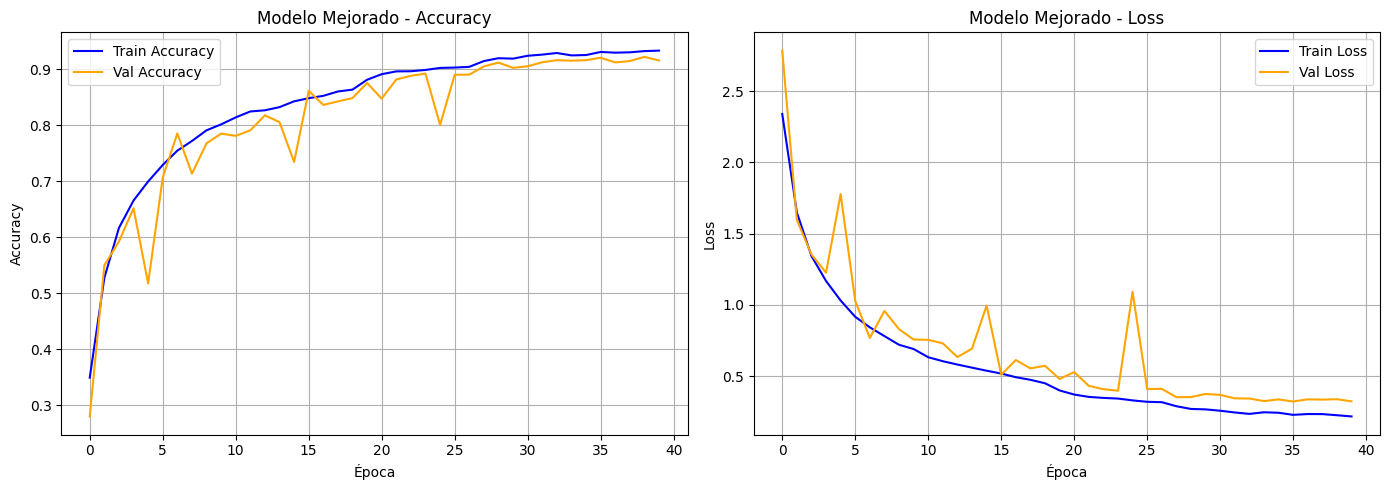

In [ ]:
# Graficamos las curvas del modelo mejorado
graficar_historial(historial_mejorado, 'Modelo Mejorado')

## 5. Evaluación del Rendimiento de los Modelos

Evaluamos ambos modelos en el conjunto de **test** (datos que nunca vio durante el entrenamiento). Usamos las métricas:

- **Accuracy:** porcentaje de predicciones correctas sobre el total
- **Precision:** de todas las veces que predijo clase X, ¿cuántas acertó?
- **Recall:** de todos los ejemplos reales de clase X, ¿cuántos detectó?
- **F1-score:** media armónica entre precision y recall (equilibrio entre ambas)

In [ ]:
# Evaluamos el modelo base en test
test_gen.reset()  # Reiniciamos el generador
loss_base, acc_base = modelo_base.evaluate(test_gen, verbose=0)
print(f'Modelo Base   → Test Accuracy: {acc_base:.4f} | Test Loss: {loss_base:.4f}')

# Evaluamos el modelo mejorado en test
test_gen.reset()
loss_mej, acc_mej = modelo_mejorado.evaluate(test_gen, verbose=0)
print(f'Modelo Mejorado → Test Accuracy: {acc_mej:.4f} | Test Loss: {loss_mej:.4f}')

Modelo Base   → Test Accuracy: 0.8184 | Test Loss: 0.7044
Modelo Mejorado → Test Accuracy: 0.9375 | Test Loss: 0.2578


### Comparación Final de Modelos

| Métrica | Modelo Base | Modelo Mejorado |
|---|---:|---:|
| Accuracy Test | 0.8184 | 0.9375 |
| Loss Test | 0.7044 | 0.2578 |
| F1-score promedio | Menor al modelo mejorado | 0.94 |

El modelo mejorado fue seleccionado como modelo final porque obtuvo mayor accuracy, menor loss y mejores métricas generales de clasificación. Esto demuestra que los ajustes realizados en la arquitectura y en los hiperparámetros tuvieron un impacto positivo en el rendimiento.

In [ ]:
# Reporte completo de clasificación (precision, recall, F1) del modelo mejorado
test_gen.reset()
predicciones = modelo_mejorado.predict(test_gen, verbose=1)
clases_pred  = np.argmax(predicciones, axis=1)
clases_real  = test_gen.classes
nombres      = list(test_gen.class_indices.keys())

print('\n--- Reporte de Clasificación: Modelo Mejorado ---')
print(classification_report(clases_real, clases_pred,
                             target_names=[n.replace('_',' ')[:15] for n in nombres]))

124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step

--- Reporte de Clasificación: Modelo Mejorado ---
                 precision    recall  f1-score   support

abraham grampa        0.91      0.95      0.93       183
apu nahasapeema       0.97      0.97      0.97       125
  barney gumble       0.93      0.59      0.72        22
   bart simpson       0.92      0.90      0.91       269
charles montgom       0.91      0.94      0.93       136
   chief wiggum       0.91      0.96      0.94       198
 comic book guy       0.93      0.86      0.90        94
 edna krabappel       0.94      0.90      0.92        92
groundskeeper w       0.88      0.84      0.86        25
  homer simpson       0.92      0.96      0.94       450
  kent brockman       0.99      0.98      0.98       100
krusty the clow       0.96      0.97      0.97       242
  lenny leonard       0.95      0.92      0.93        62
   lisa simpson       0.94      0.91      0.92       271
 maggie simpson       0.82      0.88      0.85     

### Interpretación de métricas

El reporte de clasificación permite evaluar el rendimiento del modelo más allá del accuracy. La métrica precision indica qué tan correctas fueron las predicciones positivas de cada clase, recall muestra qué proporción de imágenes reales de cada personaje fueron correctamente identificadas, y F1-score resume ambas métricas.

El modelo mejorado obtiene un F1-score promedio alto, lo que indica un buen desempeño general en la clasificación de los 25 personajes. Las clases con menor cantidad de imágenes pueden presentar métricas más bajas, lo que evidencia el efecto del desbalance de datos.

El modelo mejorado alcanza un accuracy de 0.9375 en test, superando al modelo base que obtuvo 0.8184. Además, el F1-score weighted promedio llega a 0.94, lo que indica buen rendimiento general considerando el desbalance entre clases. Algunas clases con menor cantidad de imágenes, como Barney Gumble, Maggie Simpson o Waylon Smithers, presentan menor recall o F1-score, lo que sugiere que el modelo tiene más dificultad cuando hay menos ejemplos disponibles.

### Justificación Técnica del Modelo Seleccionado

El modelo mejorado fue seleccionado debido a que logró un Accuracy de 93.75%, superando ampliamente el 81.84% obtenido por el modelo base.

Además, presentó un F1-score ponderado de 0.94 y una pérdida significativamente menor (0.2578 frente a 0.7044). Estos resultados evidencian una mejor capacidad de generalización sobre imágenes no vistas.

La mejora obtenida justifica técnicamente la incorporación de BatchNormalization, Dropout, mayor profundidad y callbacks de optimización.

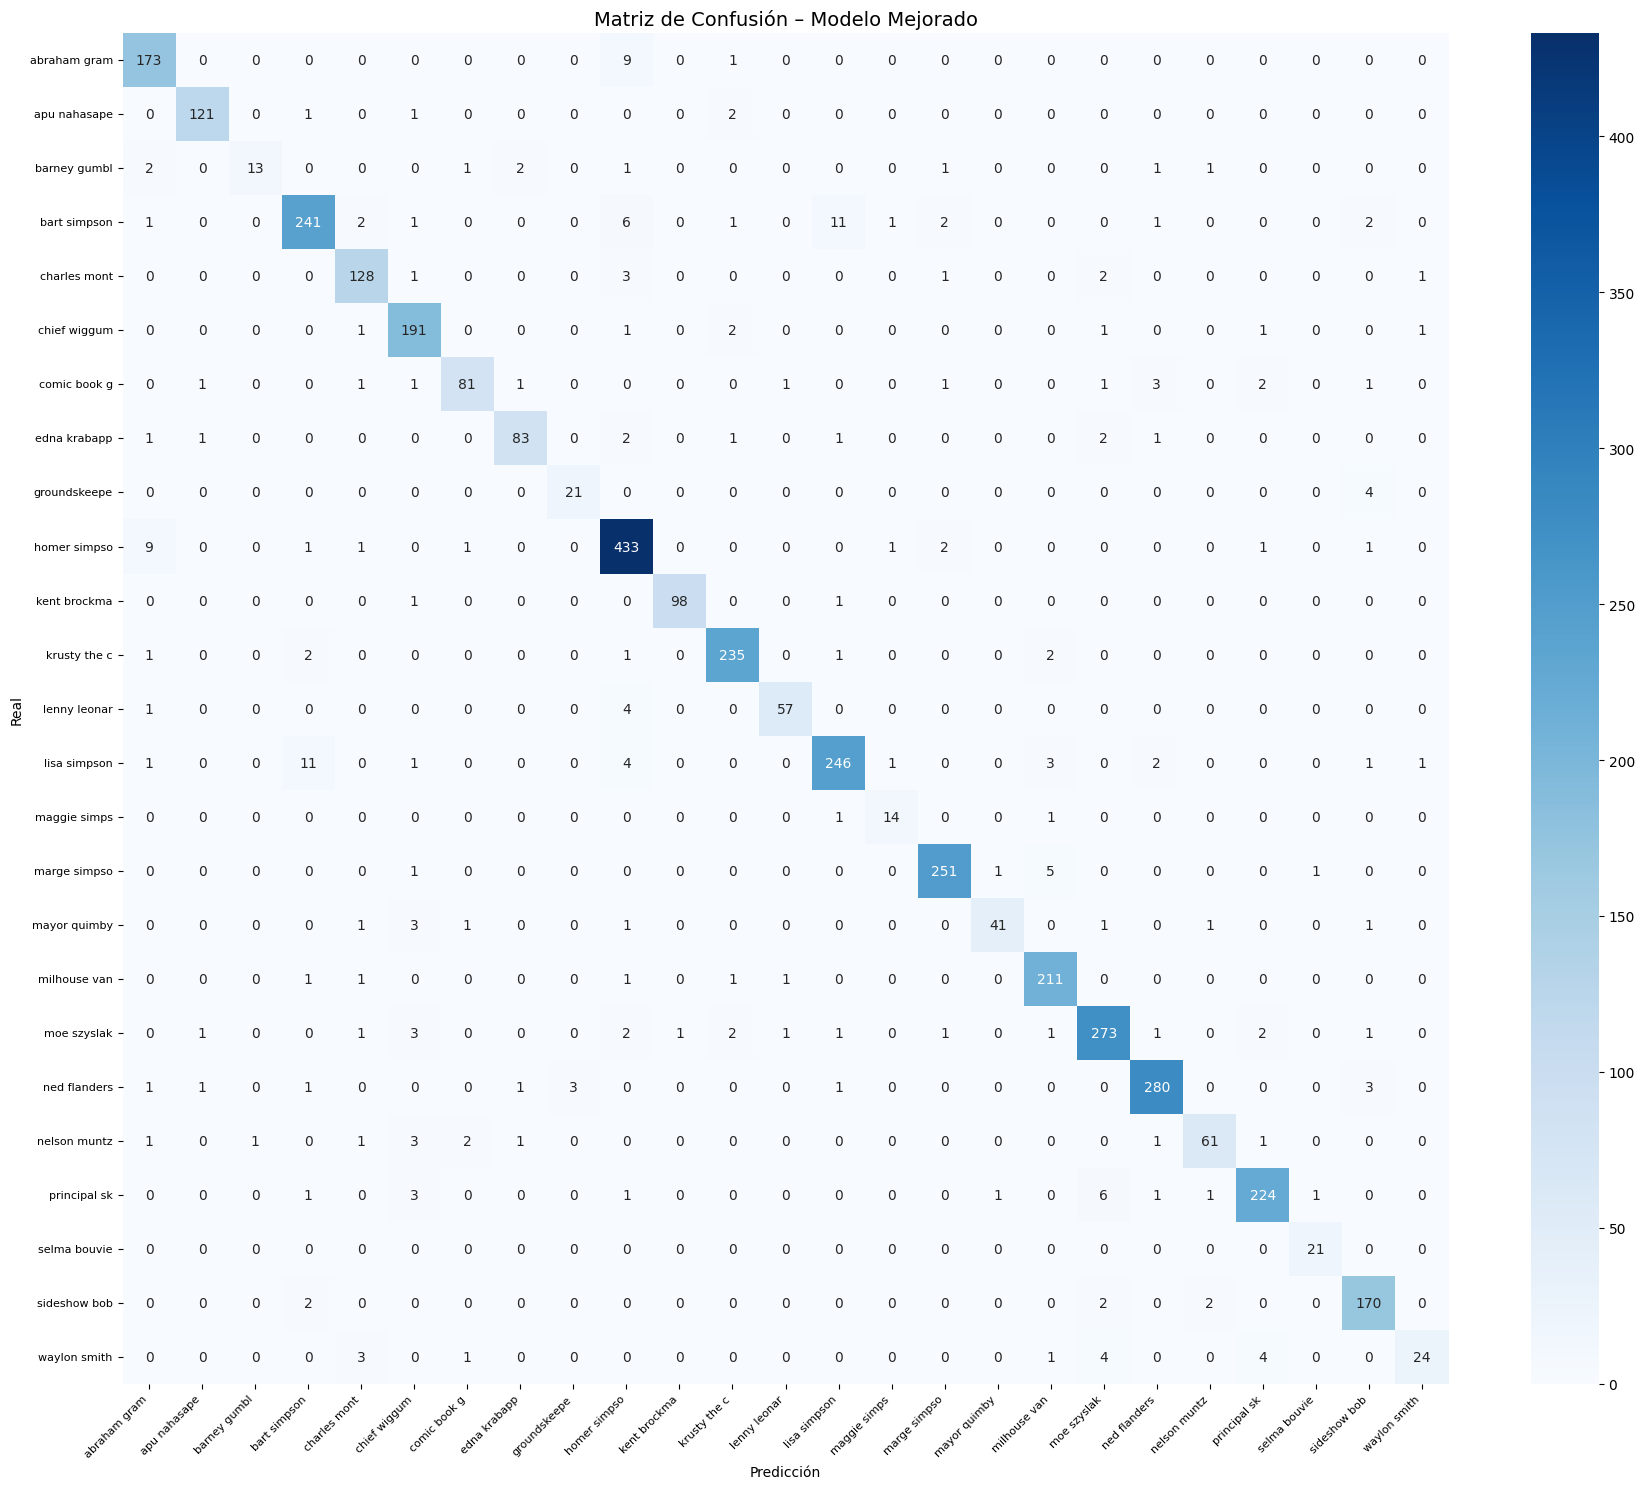

In [ ]:
# Matriz de confusión del modelo mejorado
# Muestra qué clases confunde el modelo entre sí
cm = confusion_matrix(clases_real, clases_pred)

plt.figure(figsize=(18, 15))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[n.replace('_',' ')[:12] for n in nombres],
    yticklabels=[n.replace('_',' ')[:12] for n in nombres]
)
plt.title('Matriz de Confusión – Modelo Mejorado', fontsize=14)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

## 6. Comparación de Arquitecturas y Análisis de Hiperparámetros

Comparamos directamente el Modelo Base vs el Modelo Mejorado para justificar la elección final.

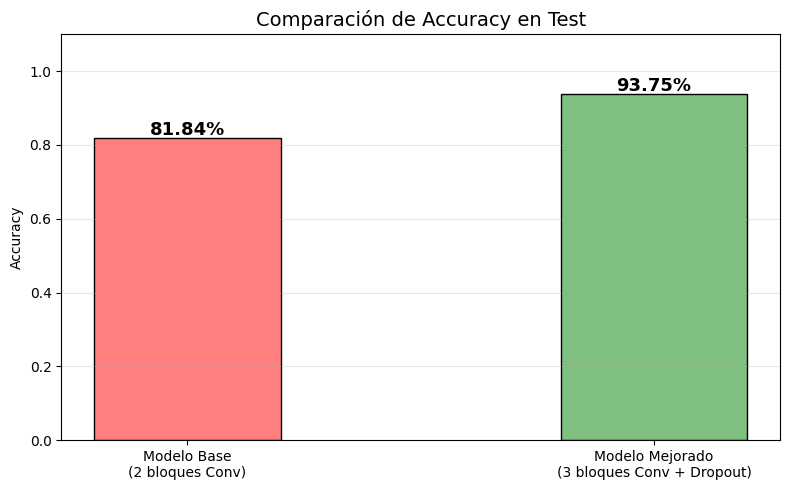

In [ ]:
# Gráfico comparativo de accuracy en test entre ambos modelos
modelos  = ['Modelo Base\n(2 bloques Conv)', 'Modelo Mejorado\n(3 bloques Conv + Dropout)']
accuracy = [acc_base, acc_mej]
colores  = ['#ff7f7f', '#7fbf7f']

plt.figure(figsize=(8, 5))
barras = plt.bar(modelos, accuracy, color=colores, edgecolor='black', width=0.4)
for barra, acc in zip(barras, accuracy):
    plt.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontsize=13, fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Comparación de Accuracy en Test', fontsize=14)
plt.ylabel('Accuracy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

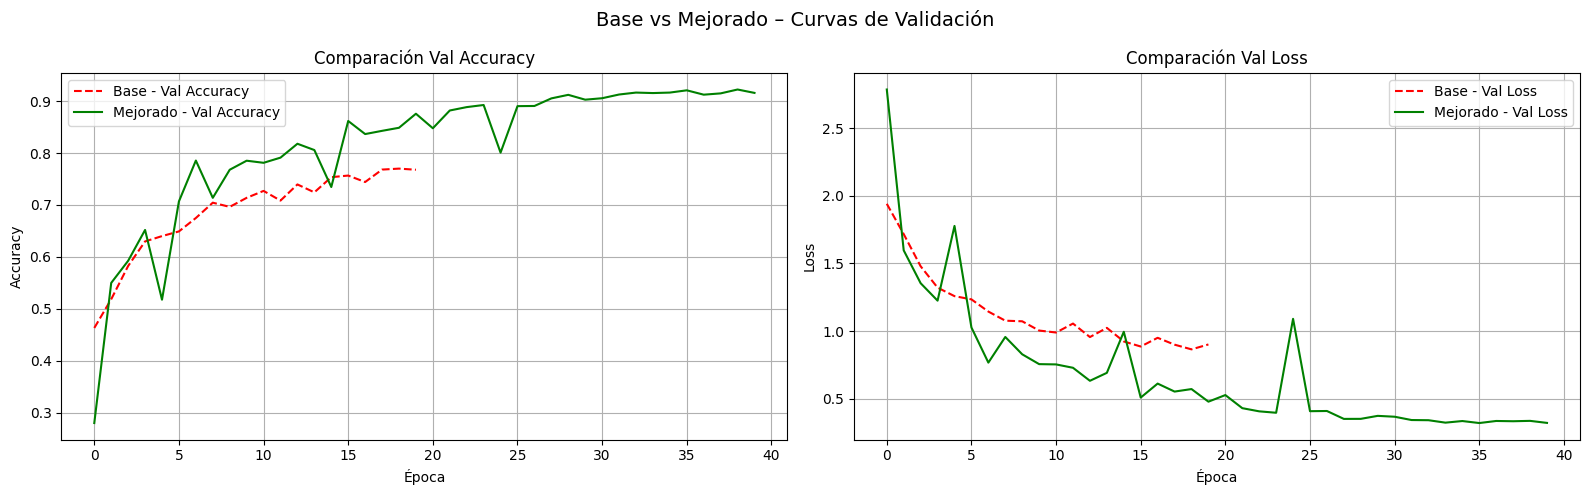


Resumen de parámetros:
  Modelo Base:     2,119,897 parámetros
  Modelo Mejorado: 2,245,561 parámetros


In [ ]:
# Comparamos las curvas de accuracy de ambos modelos en un solo gráfico
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Accuracy
axes[0].plot(historial_base.history['val_accuracy'],
             label='Base - Val Accuracy', color='red', linestyle='--')
axes[0].plot(historial_mejorado.history['val_accuracy'],
             label='Mejorado - Val Accuracy', color='green')
axes[0].set_title('Comparación Val Accuracy')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(historial_base.history['val_loss'],
             label='Base - Val Loss', color='red', linestyle='--')
axes[1].plot(historial_mejorado.history['val_loss'],
             label='Mejorado - Val Loss', color='green')
axes[1].set_title('Comparación Val Loss')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Base vs Mejorado – Curvas de Validación', fontsize=14)
plt.tight_layout()
plt.show()

print(f'\nResumen de parámetros:')
print(f'  Modelo Base:     {modelo_base.count_params():,} parámetros')
print(f'  Modelo Mejorado: {modelo_mejorado.count_params():,} parámetros')

Se selecciona el Modelo Mejorado como modelo final, ya que obtiene mayor accuracy y menor loss en test. La incorporación de más capas convolucionales, BatchNormalization y Dropout permitió mejorar la capacidad de aprendizaje y reducir el sobreajuste.

## 7. Modelo Final: Predicciones de Ejemplo

Mostramos visualmente cómo predice el modelo final en imágenes de test.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   


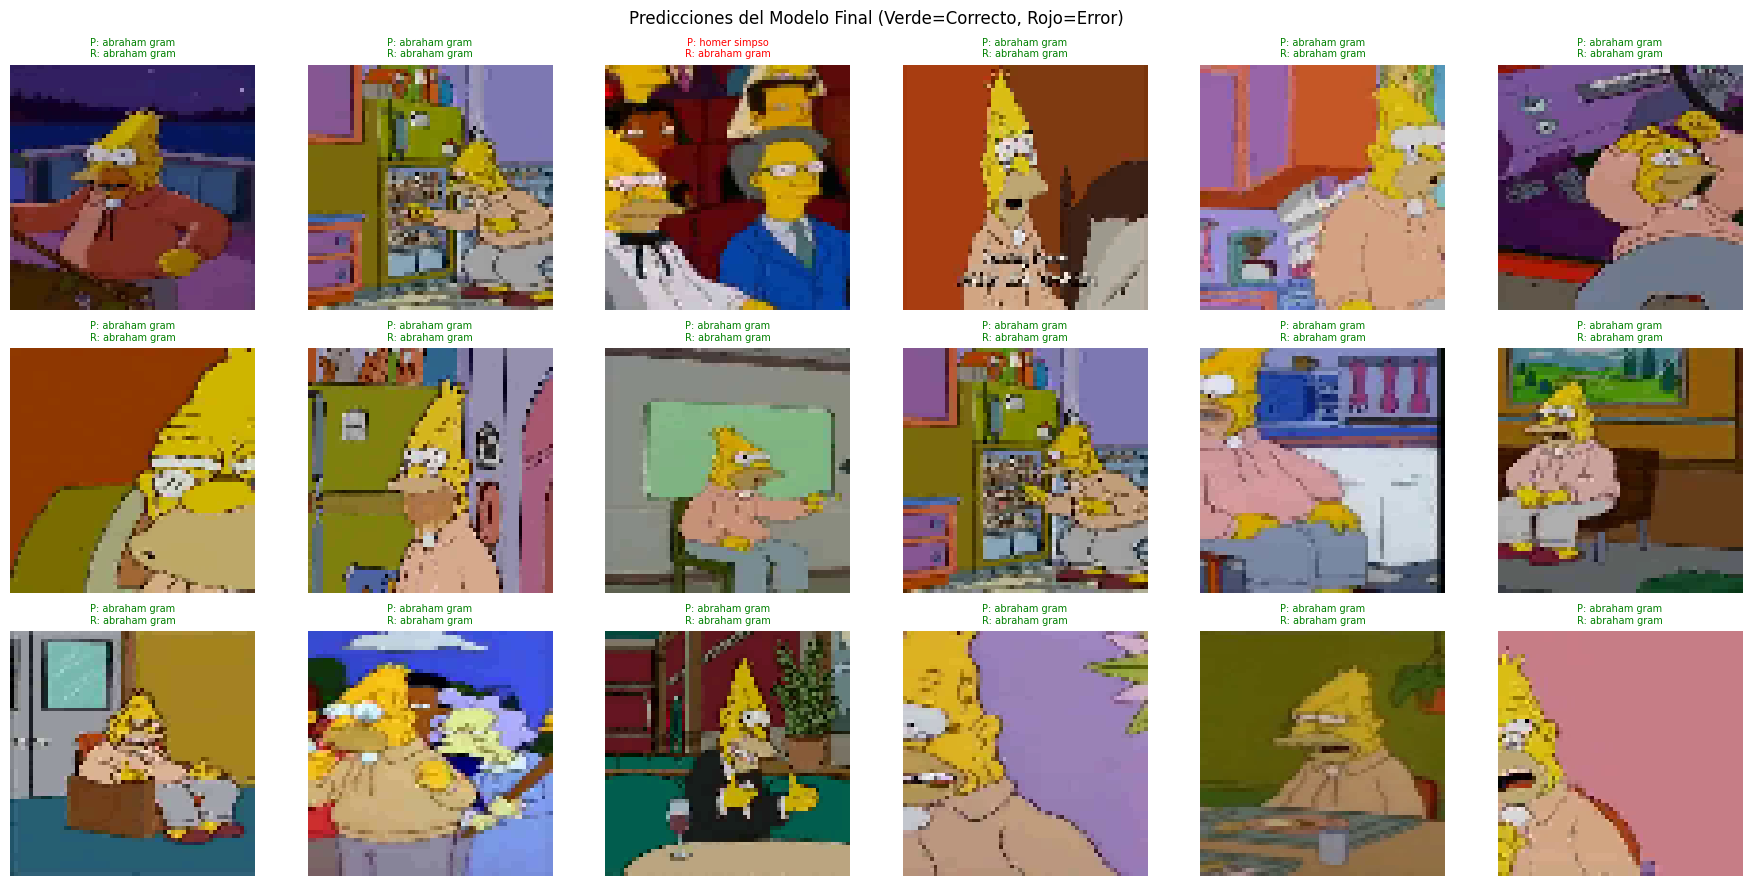

In [ ]:
# Cargamos el mejor modelo guardado durante el entrenamiento
mejor_modelo = keras.models.load_model('mejor_modelo.h5')

# Mostramos predicciones sobre imágenes del test
test_gen.reset()
imgs_test, etiq_test = next(test_gen)
preds = mejor_modelo.predict(imgs_test)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i, ax in enumerate(axes.flat):
    if i >= len(imgs_test):
        ax.axis('off')
        continue
    ax.imshow(imgs_test[i])
    pred_clase = nombres[np.argmax(preds[i])]
    real_clase = nombres[np.argmax(etiq_test[i])]
    correcta   = pred_clase == real_clase

    color  = 'green' if correcta else 'red'
    titulo = f"P: {pred_clase.replace('_',' ')[:12]}\nR: {real_clase.replace('_',' ')[:12]}"
    ax.set_title(titulo, fontsize=7, color=color)
    ax.axis('off')

plt.suptitle('Predicciones del Modelo Final (Verde=Correcto, Rojo=Error)', fontsize=12)
plt.tight_layout()
plt.show()

**Ajustes de hiperparámetros realizados**

Los principales hiperparámetros ajustados fueron la cantidad de capas convolucionales, número de filtros, tasa de Dropout, tamaño de imagen, batch size y learning rate. El modelo base utilizó una arquitectura simple con 2 bloques convolucionales, mientras que el modelo mejorado aumentó la profundidad, incorporó BatchNormalization y Dropout. Estos cambios mejoraron el rendimiento desde 81.84% a 93.75% de accuracy en test.

## 8. Conclusiones


En este trabajo se implementaron y compararon dos arquitecturas CNN para la clasificación de 25 personajes de Los Simpsons.

El modelo base obtuvo un Accuracy de 81.84%, mientras que el modelo mejorado alcanzó un Accuracy de 93.75% y un F1-score ponderado de 0.94, evidenciando una mejora significativa en el rendimiento.

Los resultados demuestran que el aumento de profundidad de la red, la incorporación de BatchNormalization, Dropout y técnicas de optimización como EarlyStopping y ReduceLROnPlateau permitieron mejorar la capacidad de generalización del modelo y reducir el sobreajuste.

A partir de las métricas obtenidas, se seleccionó el modelo mejorado como solución final, ya que presentó el mejor equilibrio entre capacidad de aprendizaje y desempeño sobre datos no vistos.

Como trabajo futuro, se propone implementar técnicas de Transfer Learning mediante arquitecturas preentrenadas como MobileNet, VGG16 o ResNet para evaluar posibles mejoras adicionales en precisión y eficiencia computacional.